# 28 — Exploratory Data Visualization & Matplotlib Figure Architecture
> **Interview Prep & Technical Mastery Guide**
> 
> *A comprehensive guide to Pandas built-in plotting routines, Object-Oriented Matplotlib architecture, chart selection principles, and production data storytelling.*

---

## 📌 Executive Summary & Interview Expectations
In technical interviews (especially for Product Data Scientist, Quantitative Researcher, and Analytics Engineer roles), data visualization is evaluated not as decorative art, but as **statistical precision, visual perception ergonomics, and clean code architecture**:
1. **The Object-Oriented Interface (`fig, ax`) vs State Machine (`plt`)**: Why production workflows reject global `plt` state in favor of explicit `Axes` objects.
2. **Chart Selection Principles**:
   - Continuous trends $\rightarrow$ **Line charts**
   - Discrete category ranking $\rightarrow$ **Horizontal Bar charts** (`kind='barh'`) with descending sort
   - Value distribution $\rightarrow$ **Histograms** (`kind='hist'`) & **Box plots** (`kind='box'`)
   - Bivariate correlation $\rightarrow$ **Scatter plots** (`kind='scatter'`)
3. **Pie Chart Cognitive Hazards**: Why data leaders discourage pie charts for $>3$ categories due to poor angle perception, and what to use instead.
4. **Secondary Y-Axes & Twin Axes**: Visualizing metrics with differing units (e.g. Total Investment vs Mission Success Rate) on the same plot.

## 1. Environment Setup & Data Ingestion

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load Space Missions dataset
space = pd.read_csv("space_missions.csv", parse_dates=["Date"], index_col="Date")
print(f"Space Missions Dataset Loaded: {space.shape[0]} launches, {space.shape[1]} columns")
space.head(4)

Matplotlib is building the font cache; this may take a moment.


Space Missions Dataset Loaded: 120 launches, 4 columns


/var/folders/54/5j97z6452x19yddj6yv2l7j00000gn/T/ipykernel_27544/3126604537.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  space = pd.read_csv("space_missions.csv", parse_dates=["Date"], index_col="Date")


,Company Name,Location,Cost,Status
Date,,,,
2019-02-05,Arianespace,France,200.00,Success
2019-02-22,SpaceX,USA,50.00,Success
2019-03-02,SpaceX,USA,50.00,Success
2019-03-09,CASC,China,29.15,Success


## 2. Continuous Temporal Trends: Line Charts (`kind='line'`)

### 💡 Best Practice: OO Matplotlib Interface
Always capture the returned `AxesSubplot` object (`ax = df.plot(...)`) to configure labels, formatting, and layout cleanly.

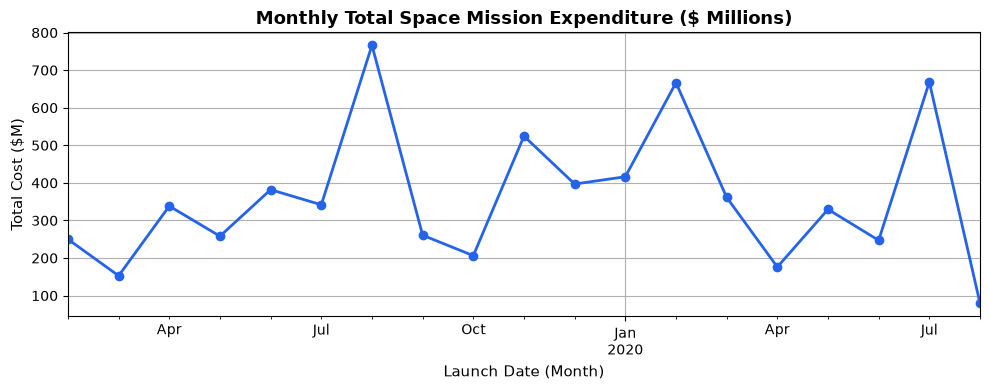

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))

# Resample cumulative mission cost by month
monthly_cost = space["Cost"].resample("ME").sum()

monthly_cost.plot(
    kind="line",
    ax=ax,
    color="#2563EB",
    marker="o",
    linewidth=2,
    grid=True
)

ax.set_title("Monthly Total Space Mission Expenditure ($ Millions)", fontsize=13, fontweight="bold")
ax.set_xlabel("Launch Date (Month)", fontsize=11)
ax.set_ylabel("Total Cost ($M)", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Categorical Comparisons: Vertical vs Horizontal Bar Charts

### 💡 Visual Ergonomics: Why Horizontal Bar Charts (`barh`) Dominate
- Vertical bar charts force category labels to rotate at $45^\circ$ or $90^\circ$, causing neck strain and poor readability.
- **Horizontal Bar Charts (`kind='barh'`)**:
  - Keep text horizontal and easy to read.
  - Accommodate long category names (e.g. company names).
  - Must be sorted with `.sort_values()` before plotting so the top category appears at the top!

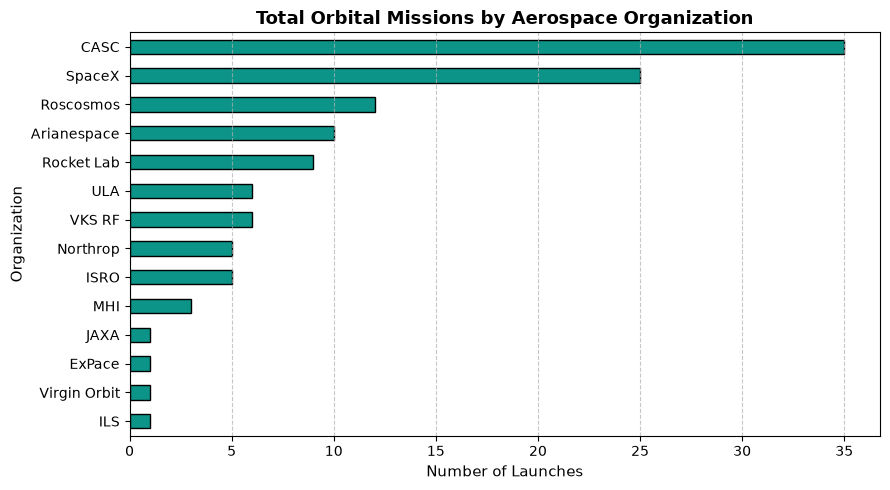

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

company_counts = (
    space["Company Name"]
    .value_counts()
    .sort_values(ascending=True)  # Ascending so highest is at top of barh
)

company_counts.plot(
    kind="barh",
    ax=ax,
    color="#0D9488",
    edgecolor="black"
)

ax.set_title("Total Orbital Missions by Aerospace Organization", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Launches", fontsize=11)
ax.set_ylabel("Organization", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Distribution Analysis: Histograms & Box Plots

### Histogram vs Box Plot Complementarity:
- **Histogram**: Displays modal density, skewness, and multi-modal clusters.
- **Box Plot**: Explicitly highlights median ($Q_2$), Interquartile Range ($Q_3 - Q_1$), whiskers ($1.5 \times \text{IQR}$), and statistical outliers.

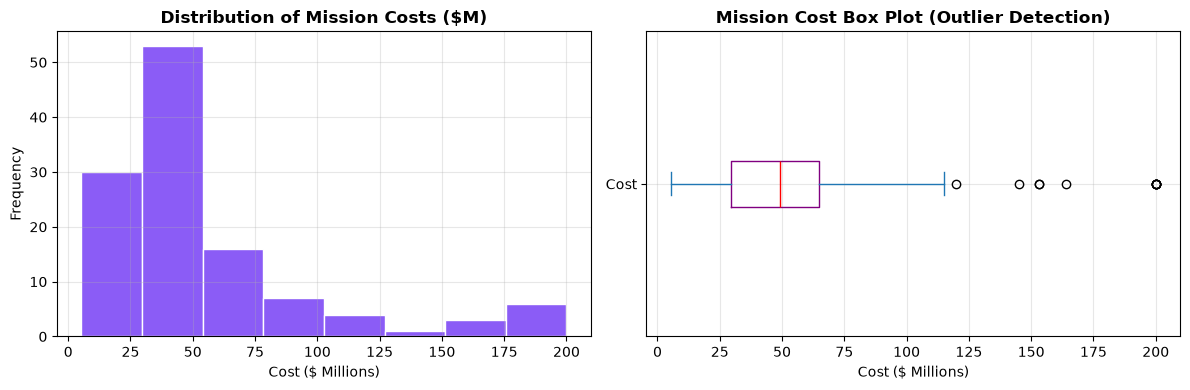

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 1. Cost Distribution Histogram
space["Cost"].plot(
    kind="hist",
    bins=8,
    ax=ax1,
    color="#8B5CF6",
    edgecolor="white"
)
ax1.set_title("Distribution of Mission Costs ($M)", fontweight="bold")
ax1.set_xlabel("Cost ($ Millions)")
ax1.grid(alpha=0.3)

# 2. Outlier Detection Box Plot
space["Cost"].plot(
    kind="box",
    ax=ax2,
    vert=False,
    color={"medians": "red", "boxes": "purple"}
)
ax2.set_title("Mission Cost Box Plot (Outlier Detection)", fontweight="bold")
ax2.set_xlabel("Cost ($ Millions)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Composition Analysis: Status Breakdown & The Pie Chart Critique

### ⚠️ Top Interview Question: "Why do senior data scientists avoid Pie Charts?"
1. **Human Angle Perception**: Humans judge linear length far more accurately than 2D angles or slice areas.
2. **Small Slice Collapse**: Slices with $<5\%$ of total volume become indistinguishable slivers.
3. **Acceptable Use**: Binary splits (e.g. Success vs Failure) with explicit percentage labels (`autopct='%1.1f%%'`).

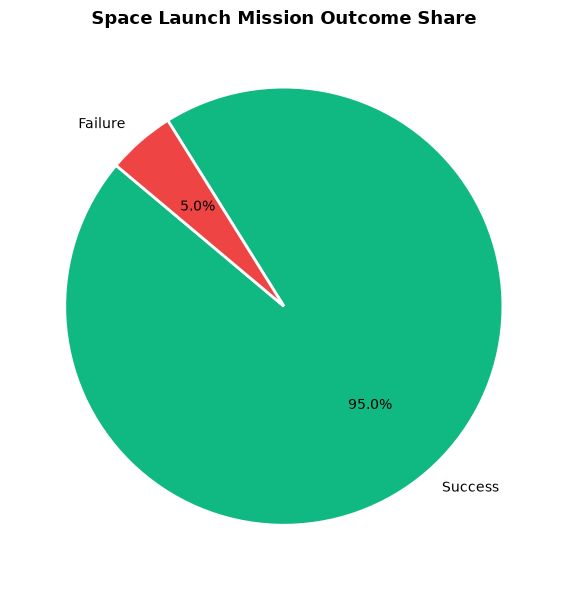

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

status_counts = space["Status"].value_counts()

status_counts.plot(
    kind="pie",
    ax=ax,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#10B981", "#EF4444"],
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

ax.set_title("Space Launch Mission Outcome Share", fontsize=13, fontweight="bold")
ax.set_ylabel("")  # Suppress default 'Status' ylabel
plt.tight_layout()
plt.show()

---
## 🎯 6. Technical Interview Corner: Tricky Questions & Drills

### Q1: What is the risk of using `plt.plot()` inside modular production functions instead of `fig, ax = plt.subplots()`?
**Answer**:
The `plt` module relies on a global, stateful backend tracker ("current active figure" and "current active axes"). If a function calls `plt.plot()`, it implicitly modifies whatever figure is currently active in memory. In multi-threaded environments, asynchronous jobs, or complex loops generating multiple figures, this causes figures to overwrite each other's data or leak memory. The Object-Oriented interface (`fig, ax`) binds drawing calls strictly to explicitly instantiated instances.

---

### Q2: Advanced Interview Coding Challenge: Dual-Axis Performance Dashboard
**Challenge**:
For the top 4 companies by total launches:
1. Calculate the **Total Spend ($M)** and the **Success Rate (%)** ($(\text{Successes} / \text{Total}) \times 100$).
2. Plot both metrics on a single chart with **twin axes** (`ax.twinx()`):
   - Bars on the primary axis for Total Spend.
   - A line with markers on the secondary axis for Success Rate!

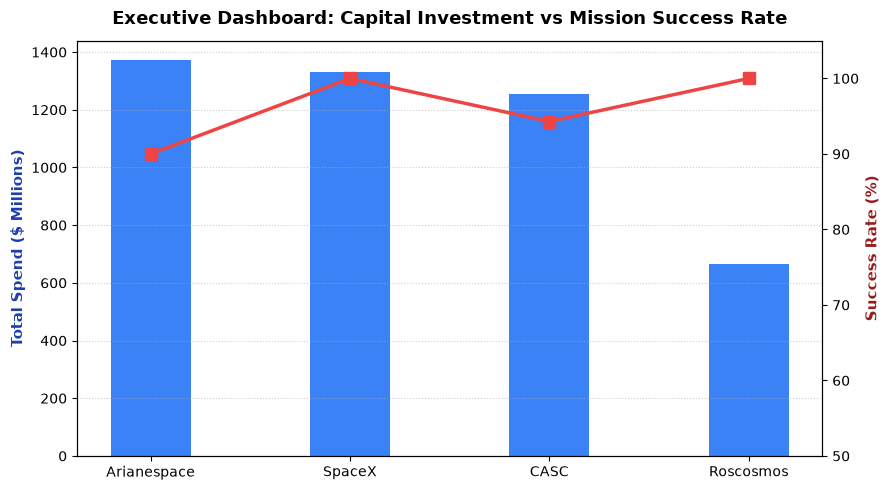

In [6]:
# Interview Solution: Twin-Axis Executive Dashboard
# 1. Compute company performance aggregates
top_companies = space["Company Name"].value_counts().head(4).index
company_metrics = (
    space[space["Company Name"].isin(top_companies)]
    .groupby("Company Name")
    .agg(
        total_spend=("Cost", "sum"),
        success_rate=("Status", lambda s: (s == "Success").mean() * 100)
    )
    .sort_values(by="total_spend", ascending=False)
)

# 2. Build Dual-Axis Figure
fig, ax1 = plt.subplots(figsize=(9, 5))

# Primary Axis: Total Spend (Bars)
x_positions = np.arange(len(company_metrics))
bars = ax1.bar(x_positions, company_metrics["total_spend"], width=0.4, color="#3B82F6", label="Total Spend ($M)")
ax1.set_ylabel("Total Spend ($ Millions)", color="#1E40AF", fontsize=11, fontweight="bold")
ax1.set_xticks(x_positions)
ax1.set_xticklabels(company_metrics.index, fontsize=10)
ax1.grid(axis="y", linestyle=":", alpha=0.6)

# Secondary Axis: Success Rate (Line with markers)
ax2 = ax1.twinx()
line = ax2.plot(x_positions, company_metrics["success_rate"], color="#EF4444", marker="s", linewidth=2.5, markersize=8, label="Success Rate (%)")
ax2.set_ylabel("Success Rate (%)", color="#991B1B", fontsize=11, fontweight="bold")
ax2.set_ylim(50, 105)

plt.title("Executive Dashboard: Capital Investment vs Mission Success Rate", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()